<a href="https://colab.research.google.com/github/Milanjavoor/AI-Learning/blob/main/F1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ERROR: Could not find a version that satisfies the requirement Conv1D (from versions: none)
ERROR: No matching distribution found for Conv1D
Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
Path to dataset files: /kaggle/input/formula-1-world-championship-1950-2020
   driverId   driverRef number code  forename     surname         dob  \
0         1    hamilton     44  HAM     Lewis    Hamilton  1985-01-07   
1         2    heidfeld     \N  HEI      Nick    Heidfeld  1977-05-10   
2         3     rosberg      6  ROS      Nico     Rosberg  1985-06-27   
3         4      alonso     14  ALO  Fernando      Alonso  1981-07-29   
4         5  kovalainen     \N  KOV    Heikki  Kovalainen  1981-10-19   

  nationality                                             url  
0     British     http://en.wikipedia.org/wiki/Lewis_Hamilton  
1      German      http://en.wikipedia.org/wiki/Nick_Heidfeld  
2      German       http://en.wikipedia.org/wiki/Nico_Rosbe

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9553 - loss: 0.1481 - val_accuracy: 0.9589 - val_loss: 0.1113
Epoch 2/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9575 - loss: 0.1280 - val_accuracy: 0.9587 - val_loss: 0.1161
Epoch 3/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9574 - loss: 0.1241 - val_accuracy: 0.9573 - val_loss: 0.1105
Epoch 4/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9575 - loss: 0.1198 - val_accuracy: 0.9580 - val_loss: 0.1096
Epoch 5/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9576 - loss: 0.1218 - val_accuracy: 0.9587 - val_loss: 0.1153
Epoch 6/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9575 - loss: 0.1189 - val_accuracy: 0.9587 - val_loss: 0.1014
Epoch 7/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9575 - loss: 0.1171 - val_accuracy: 0.9587 - val_loss: 0.1059
Epoch 8/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9575 - loss: 0.1149 - val_accuracy: 0.

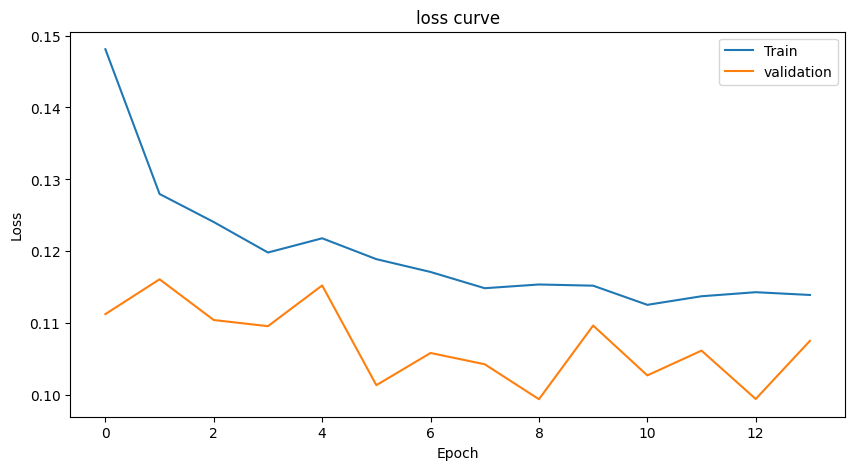

168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9574 - loss: 0.1135
model accuracy is 0.9573991298675537
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [7]:
from sklearn.utils import validation
from numpy.random import test
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as srs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
!pip install tensorflow  keras Conv1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
# Download latest version
path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")

print("Path to dataset files:", path)
import tensorflow as tf
from tensorflow.keras.models import Sequential
drivers=pd.read_csv(
   "/kaggle/input/formula-1-world-championship-1950-2020/drivers.csv"
)

results = pd.read_csv(
    "/kaggle/input/formula-1-world-championship-1950-2020/results.csv"
)

races = pd.read_csv(
    "/kaggle/input/formula-1-world-championship-1950-2020/races.csv"
)

constructors = pd.read_csv(
    "/kaggle/input/formula-1-world-championship-1950-2020/constructors.csv"
)

quali = pd.read_csv(
    "/kaggle/input/formula-1-world-championship-1950-2020/qualifying.csv"
)
print(drivers.head())
print(drivers.shape)
print(results.shape)
print(constructors.head())
print(results.isnull().sum())
print(races.isnull().sum())
print(drivers.isnull().sum())
constructors=constructors.dropna()
quali=quali.dropna()
print(results.columns)
results["winner"]=(results["positionOrder"]==1).astype(int)
df=results.merge(
    races,
    on=["raceId"],
    how="left",
)
df=df.merge(
    drivers,
    on=["driverId"],
    how="left"
)
df=df.merge(
    quali,
    on=["raceId","driverId"],
    how="left"
)
df=df.merge(
    constructors,
    left_on='constructorId_x',
    right_on="constructorId",
    how="left"
)
print(df.head())
print(df.shape)
df["age"]=df["year"]-df["dob"].str[:4].astype(int)
print(df.columns)

df["pole position"]=(
    df['position_x']==1
).astype(int)
df["podium"]=(
    df["positionOrder"]<=3
).astype(int)
features=["grid","laps","year","round","age","pole position"
]
target="winner"
x=df[features]
y=df[target]
scalar=StandardScaler()
xscaled=scalar.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(xscaled,y,test_size=0.2,random_state=42)
x_train=x_train.reshape(
    x_train.shape[0],
    x_train.shape[1],1
)
x_test=x_test.reshape(
    x_test.shape[0],
    x_test.shape[1],
    1
)
model=Sequential()
model.add(
    Conv1D(
        filters=64,
        kernel_size=2,
        activation="relu",
        input_shape=(x_train.shape[1],1)
    )
)
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))
model.add(
    Conv1D(
        filters=128,
        activation="relu",
        kernel_size=2
    )
)
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(64,activation="relu"))
model.add(Dense(1,activation="sigmoid"))
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
earlystop=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
history=model.fit(
  x_train,y_train,
   epochs=50,
  batch_size=32,
  validation_split=0.2,
  callbacks=[earlystop]
)
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","validation"])
plt.show()
testloss,testaccuracy=model.evaluate(
    x_test,
    y_test
)
print("model accuracy is",testaccuracy)
predictions=model.predict(x_test)